In [ ]:
import time
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
plt.style.use('ggplot')

from sklearn.ensemble import HistGradientBoostingRegressor

from cluster_experiments import (
    NonClusteredSplitter,
    ClusteredSplitter,
    SwitchbackSplitter,
    ConstantWashover,
    ConstantPerturbator,
    NormalPerturbator,
    ClusteredOLSAnalysis,
    OLSAnalysis,
    PowerAnalysis,
    NormalPowerAnalysis,
    AnalysisPlan,
    SimpleMetric,
    Dimension,
    Variant,
    HypothesisTest
)

# Data Generation

In [2]:
def generate_data(sample_size=50_000, seed=42) -> pd.DataFrame:
    rng = np.random.default_rng(seed=seed)

    N_CUSTOMERS = sample_size
    MIN_DATE = pd.Timestamp('2021-01-01')
    MAX_DATE = MIN_DATE + pd.Timedelta(days=360)
    
    customer_ids = rng.choice(np.arange(1e6, 1e7).astype(int), size=N_CUSTOMERS, replace=False)
    beta_samples = rng.beta(2, 5, size=N_CUSTOMERS)
    customer_mean_time_between_orders = 7 + (60 - 7) * (1 - beta_samples) # Every customer has a different mean time between orders
    customer_average_spend = rng.uniform(20, 200, size=N_CUSTOMERS) # Every customer has a different average spend
    start_times = rng.choice(pd.date_range(MIN_DATE.replace(year=2020), MAX_DATE.replace(year=2020)), size=N_CUSTOMERS, replace=True) # Every customer places their first order sometime in 2020
    orders = []
    for customer_id, start_time, time_between_orders, avg_spend in zip(
        customer_ids,
        start_times,
        customer_mean_time_between_orders,
        customer_average_spend
    ):
        order_time = start_time
        while order_time < MAX_DATE: # Generate orders until MAX_DATE
            order_time = order_time + pd.Timedelta(days=rng.exponential(scale=time_between_orders))
            if order_time >= MIN_DATE: # Only keep orders after MIN_DATE
                order_value = np.round(rng.normal(loc=avg_spend, scale=avg_spend * 0.3), 2)
                orders.append({
                    'customer_id': customer_id,
                    'order_time': order_time,
                    'order_value': max(0, order_value)
                })
    data = (
        pd.DataFrame(orders)
        .sample(frac=1, random_state=seed, replace=False)
        .reset_index(drop=True)
        .assign(
            time_index = lambda df: (df['order_time'] - df['order_time'].min()).dt.days
        )
    )

    return data

In [3]:
data = generate_data(
    sample_size=50_000,
    seed=42
)

In [4]:
data.describe(include='all').T

,count,mean,min,25%,50%,75%,max,std
customer_id,468132.0,5500418.196763,1000007.0,3250486.0,5509827.0,7738731.0,9999735.0,2597416.147194
order_time,468132,2021-07-23 21:51:26.751543040,2021-01-01 00:00:12.561854914,2021-04-11 11:28:23.292938240,2021-07-21 13:12:32.292747008,2021-10-30 02:05:19.766682112,2023-09-07 22:39:28.742029417,NaN
order_value,468132.0,109.823195,0.0,58.11,101.03,152.11,429.74,63.22415
time_index,468132.0,203.411125,0.0,100.0,201.0,302.0,979.0,121.294939


# Clustered Design

### Helper functions

In [5]:
def get_cupac_df(
    pre_df:pd.DataFrame,
    post_df:pd.DataFrame,
    cluster_cols: list[str]
    ) -> pd.DataFrame:
    agg_pre_df = (
        pre_df
        .groupby(
            by = cluster_cols,
            as_index = False
        )
        .agg(
            pre_n_orders = ('order_time', 'count'),
            pre_aov = ('order_value', 'mean')
        )
    )
    cupac_df = (
        pd.merge(
            left = post_df,
            right = agg_pre_df,
            on = cluster_cols
        )
        .fillna(0)
    )
    return cupac_df

### Data definition

In [6]:
cluster_cols = ['customer_id']
feature_cols = [
    'pre_n_orders',
    'pre_aov'
]
target_col = 'order_value'
time_col = 'order_time'
average_effect = 1

In [7]:
cupac_training_data = (
    data
    .query('time_index < 90')
    .reset_index(drop=True)
)
print(f'{cupac_training_data.shape=}')

pre_experiment_data = (
    data
    .query('90 <= time_index < 180')
    .reset_index(drop=True)
)
print(f'{pre_experiment_data.shape=}')

experiment_design_data = (
    data
    .query('180 <= time_index < 270')
    .reset_index(drop=True)
)
print(f'{experiment_design_data.shape=}')

cupac_training_data.shape=(104628, 4)
pre_experiment_data.shape=(104703, 4)
experiment_design_data.shape=(104345, 4)


## Listing: Simulation-based power estimation under a clustered design

In [8]:
splitter = ClusteredSplitter(
    cluster_cols=cluster_cols,
)
perturbator = ConstantPerturbator(
    target_col=target_col
)
analysis = ClusteredOLSAnalysis(
    cluster_cols=cluster_cols,
    target_col=target_col
)

In [9]:
sim_power_analysis = PowerAnalysis(
    perturbator=perturbator,
    splitter=splitter,
    analysis=analysis,
    target_col=target_col,
    seed = 42
)
start = time.time()
power_sim = sim_power_analysis.power_analysis(
    df=experiment_design_data,
    average_effect= average_effect,
    n_simulations = 1000,
    n_jobs=10
)
end = time.time()
duration = end - start

In [10]:
print(f'Estimated Power (Simulation): {power_sim:.3f} in {duration:.2f} seconds')

Estimated Power (Simulation): 0.359 in 32.79 seconds


### Compare with analytical approach

In [11]:
normal_power_analysis = NormalPowerAnalysis(
    splitter=splitter,
    analysis=analysis,
    target_col=target_col
)
start = time.time()
power_normal = normal_power_analysis.power_analysis(
    df=experiment_design_data,
    average_effect=average_effect,
    n_simulations=10,
)
end = time.time()
duration = end - start

In [12]:
print(f'Estimated Power (Analytical): {power_normal:.3f} in {duration:.2f} seconds')

Estimated Power (Analytical): 0.372 in 1.58 seconds


## Listing: Simulation-based power estimation under a clustered design with CUPAC

In [13]:
cupac_training_data = get_cupac_df(
    pre_df = cupac_training_data,
    post_df = pre_experiment_data,
    cluster_cols=cluster_cols
)
cupac_experiment_data = get_cupac_df(
    pre_df = pre_experiment_data,
    post_df = experiment_design_data,
    cluster_cols=cluster_cols
)

In [14]:
analysis = ClusteredOLSAnalysis(
    cluster_cols=cluster_cols,
    target_col=target_col,
    covariates=['estimate_' + target_col]
)

In [15]:
sim_power_analysis_cupac = PowerAnalysis(
    perturbator=perturbator,
    splitter=splitter,
    analysis=analysis,
    target_col=target_col,
    cupac_model = HistGradientBoostingRegressor(),
    features_cupac_model=feature_cols
)

start = time.time()
power_sim_cupac = sim_power_analysis_cupac.power_analysis(
    df=cupac_experiment_data,
    average_effect= average_effect,
    n_simulations = 100,
    pre_experiment_df=cupac_training_data,
    n_jobs=10
)
end = time.time()
duration = end - start

In [16]:
print(f'Estimated Power (Simulation with CUPAC): {power_sim_cupac:.3f} in {duration:.2f} seconds')

Estimated Power (Simulation with CUPAC): 0.800 in 5.91 seconds


# Non-Clustered Design

### Helper function

In [17]:
def get_cupac_df(
    pre_df:pd.DataFrame,
    post_df:pd.DataFrame,
    cluster_cols: list[str]
    ) -> pd.DataFrame:
    cupac_df = (
        pd.merge(
            left = post_df,
            right = pre_df.rename(columns={'n_orders': 'pre_n_orders'}),
            on = cluster_cols,
            how='left',
            suffixes = ('', '_pre')
        )
        .fillna(0)
    )
    return cupac_df

### Data definitions

In [18]:
feature_cols = [
    'pre_n_orders'
]
target_col = 'n_orders'
time_col = 'first_order_time'
average_effect = 0.01

In [19]:
cupac_training_data = (
    data
    .query('time_index < 90')
    .groupby(
        by = ['customer_id'],
        as_index = False
    )
    .agg(
        n_orders = ('order_time', 'count'),
        first_order_time = ('order_time', 'min')
    )
    .astype({'n_orders': float})
    .reset_index(drop=True)
)
print(f'{cupac_training_data.shape=}')

pre_experiment_data = (
    data
    .query('90 <= time_index < 180')
    .groupby(
        by = ['customer_id'],
        as_index = False
    )
    .agg(
        n_orders = ('order_time', 'count'),
        first_order_time = ('order_time', 'min')
    )
    .astype({'n_orders': float})
    .reset_index(drop=True)
)
print(f'{pre_experiment_data.shape=}')

experiment_design_data = (
    data
    .query('180 <= time_index < 270')
    .groupby(
        by = ['customer_id'],
        as_index = False
    )
    .agg(
        n_orders = ('order_time', 'count'),
        first_order_time = ('order_time', 'min')
    )
    .astype({'n_orders': float})
    .reset_index(drop=True)
)
print(f'{experiment_design_data.shape=}')

cupac_training_data.shape=(43235, 3)
pre_experiment_data.shape=(43221, 3)
experiment_design_data.shape=(43100, 3)


## Listing: Comparing power estimations between simulation and analytical approaches

In [20]:
splitter = NonClusteredSplitter()
perturbator = ConstantPerturbator(
    target_col=target_col
)
analysis = OLSAnalysis(
    target_col=target_col
)

sim_power_analysis = PowerAnalysis(
    splitter=splitter,
    perturbator=perturbator,
    analysis=analysis,
    target_col=target_col,
    n_simulations=100
)

start = time.time()
sim_power = sim_power_analysis.power_analysis(
    df=experiment_design_data,
    average_effect=average_effect,
    n_simulations=1000,
    n_jobs=10
)
end = time.time()
sim_duration = end - start

In [21]:
print(f'Estimated Power (Simulation): {sim_power:.3f} in {sim_duration:.2f} seconds')

Estimated Power (Simulation): 0.110 in 5.65 seconds


In [25]:
normal_power_analysis = NormalPowerAnalysis(
    splitter=splitter,
    analysis=analysis,
    target_col=target_col,
    time_col=time_col
)
start = time.time()
normal_power = normal_power_analysis.power_analysis(
    df=experiment_design_data,
    average_effect=average_effect,
    n_simulations=1
)
end = time.time()
normal_duration = end - start

In [26]:
print(f'Estimated Power (Analytical): {normal_power:.3f} in {normal_duration:.2f} seconds')

Estimated Power (Analytical): 0.117 in 0.04 seconds


## Listing: Using the `mde_time_line` method

<Axes: xlabel='experiment_length', ylabel='mde'>

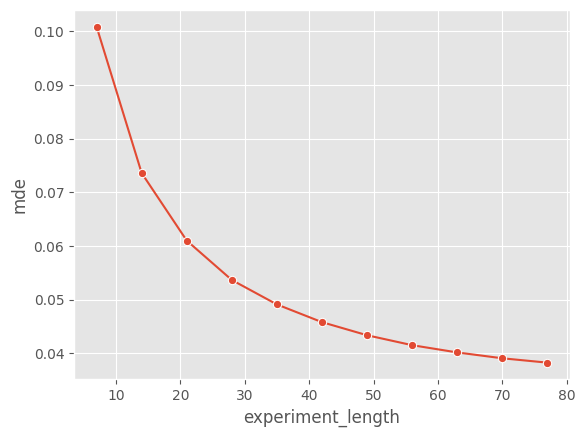

In [27]:
mde_time_line = normal_power_analysis.mde_time_line(
    df = experiment_design_data,
    experiment_length = np.arange(7, 7*12, 7),
    alpha = 0.05,
    powers=[0.8]
)
mde_time_line_df = pd.DataFrame(mde_time_line)
sns.lineplot(
    data=mde_time_line_df,
    x='experiment_length',
    y='mde',
    marker='o'
)

# Switchback

### Data Definition

In [28]:
target_col = 'order_value'
time_col = 'order_time'
average_effect = 1

In [29]:
experiment_design_data = (
    data
    .query('180 <= time_index < 270')
    .reset_index(drop=True)
)
print(f'{experiment_design_data.shape=}')

experiment_design_data.shape=(104345, 4)


## Listing: Switchback deisgn with simulation-based power estimation

In [30]:
washover = ConstantWashover(
    washover_time_delta = '30m'
)
splitter = SwitchbackSplitter(
    time_col = time_col,
    switch_frequency='1h',
    cluster_cols = ['order_time'],
    washover=washover
)
perturbator = ConstantPerturbator(
    target_col=target_col
)
analysis = ClusteredOLSAnalysis(
    cluster_cols=['order_time'],
    target_col=target_col
)
switchback_power_analysis = PowerAnalysis(
    splitter=splitter,
    perturbator=perturbator,
    analysis=analysis,
    target_col=target_col
)
switchback_power = switchback_power_analysis.power_analysis(
    df=experiment_design_data,
    average_effect= average_effect,
    n_simulations = 100,
    n_jobs=10
)
print(f'Estimated Power (Switchback): {switchback_power:.3f}')

Estimated Power (Switchback): 0.650


# Experiment Analysis

### Helper function

In [31]:
def get_cupac_df(
    pre_df:pd.DataFrame,
    post_df:pd.DataFrame,
    cluster_cols: list[str]
    ) -> pd.DataFrame:
    agg_pre_df = (
        pre_df
        .groupby(
            by = cluster_cols,
            as_index = False
        )
        .agg(
            pre_n_orders = ('order_time', 'count'),
            pre_aov = ('order_value', 'mean')
        )
    )
    cupac_df = (
        pd.merge(
            left = post_df,
            right = agg_pre_df,
            on = cluster_cols
        )
        .fillna(0)
    )
    return cupac_df

### Data Definition

In [32]:
cluster_cols = ['customer_id']
feature_cols = [
    'pre_n_orders',
    'pre_aov'
]
target_col = 'order_value'
time_col = 'order_time'
average_effect = 1

In [33]:
pre_experiment_data = (
    data
    .query('90 <= time_index < 180')
    .reset_index(drop=True)
)
print(f'{pre_experiment_data.shape=}')

experiment_design_data = (
    data
    .query('180 <= time_index < 270')
    .reset_index(drop=True)
)
print(f'{experiment_design_data.shape=}')

_experiment_analysis_data = (
    data
    .query('270 <= time_index < 360')
    .reset_index(drop=True)
)
print(f'{_experiment_analysis_data.shape=}')

pre_experiment_data.shape=(104703, 4)
experiment_design_data.shape=(104345, 4)
_experiment_analysis_data.shape=(104456, 4)


### Data pre-processing

In [34]:
city_assigner = ClusteredSplitter(
    cluster_cols=cluster_cols,
    treatment_col='city_code',
    treatments=['MAD', 'BCN'],
    splitter_weights=[0.7, 0.3]
)
treatment_assigner = ClusteredSplitter(
    cluster_cols=cluster_cols,
    treatment_col='variant',
    treatments=['A', 'B'],
)
treatment_perturbator = NormalPerturbator(
    target_col = target_col,
    treatment_col='variant',
    treatment='B',
    average_effect=1,
    scale=1
)
    
experiment_analysis_data = (
    _experiment_analysis_data
    .pipe(city_assigner.assign_treatment_df)
    .pipe(treatment_assigner.assign_treatment_df)
    .pipe(treatment_perturbator.perturbate)
)

## Listing: Experiment analysis example

In [35]:
metric__order_value = SimpleMetric(
    alias = 'AOV',
    name = 'order_value'
)

dimension__city_code = Dimension(
    name = 'city_code',
    values = ['MAD', 'BCN'],
)

variant__control = Variant(
    name = 'A',
    is_control = True
)
variant__treatment = Variant(
    name = 'B',
    is_control = False
)

test__order_value = HypothesisTest(
    metric = metric__order_value,
    dimensions=[dimension__city_code],
    analysis_type = 'clustered_ols',
    analysis_config = {
        'target_col': target_col,
        'cluster_cols': cluster_cols,
        'covariates': ['estimate_' + target_col]
    },
    cupac_config = {
        'cupac_model': HistGradientBoostingRegressor(),
        'target_col': target_col,
        'features_cupac_model': feature_cols
    }
)

analysis_plan = AnalysisPlan(
    tests = [test__order_value],
    variants = [variant__control, variant__treatment],
    variant_col = 'variant',
    alpha = 0.05
)

analysis_results = (
    analysis_plan
    .analyze(
        exp_data = get_cupac_df(
            pre_df = experiment_design_data,
            post_df = experiment_analysis_data,
            cluster_cols=cluster_cols
        ),
        pre_exp_data = get_cupac_df(
            pre_df = pre_experiment_data,
            post_df = experiment_design_data,
            cluster_cols=cluster_cols
        )
    )
    .to_dataframe()
)   

In [36]:
print(analysis_results)

  metric_alias control_variant_name treatment_variant_name  \
0          AOV                    A                      B   
1          AOV                    A                      B   
2          AOV                    A                      B   

   control_variant_mean  treatment_variant_mean  analysis_type       ate  \
0            109.377970              111.090032  clustered_ols  0.934843   
1            109.791109              110.548946  clustered_ols  1.106068   
2            108.408189              112.419319  clustered_ols  0.559638   

   ate_ci_lower  ate_ci_upper   p_value  std_error     dimension_name  \
0      0.256057      1.613628  0.006948   0.346325  __total_dimension   
1      0.294800      1.917337  0.007536   0.413920          city_code   
2     -0.682511      1.801787  0.377213   0.633761          city_code   

  dimension_value  alpha  
0           total   0.05  
1             MAD   0.05  
2             BCN   0.05  
